In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [13]:
class AgentState(TypedDict):
    message: str

In [ ]:
def greeting_node(state: AgentState) -> AgentState:
    """Simple node that add a greeting message to the state"""
    state["message"] = f"Hey {state['message']}, how is your day?"
    return state

In [15]:
graph = StateGraph(state_schema=AgentState)

graph.add_node(node="greeting_node", action=greeting_node)
graph.set_entry_point(key="greeting_node")
graph.set_finish_point(key="greeting_node")

app = graph.compile()

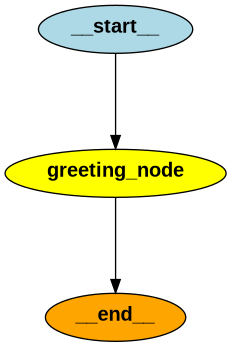

In [16]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_png()))

In [17]:
result = app.invoke(input={"message": "hi"})

In [18]:
result["message"]

'Hey hi, how is your day?'

# Excercise

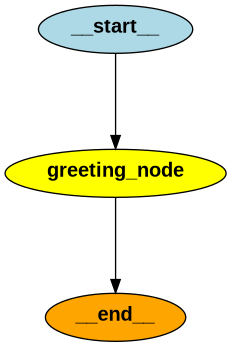

In [22]:
class AgentState(TypedDict):
    message: str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that add a greeting message to the state"""
    state["message"] += ", you are doing an amazing job learning LangGraph."
    return state


graph = StateGraph(state_schema=AgentState)

graph.add_node(node="greeting_node", action=greeting_node)
graph.set_entry_point(key="greeting_node")
graph.set_finish_point(key="greeting_node")

app = graph.compile()

display(Image(app.get_graph().draw_png()))

In [23]:
result = app.invoke(input={"message": "hi"})

In [24]:
result

{'message': 'hi, you are doing an amazing job learning LangGraph.'}